# Logistische Regression – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/logistische-regression)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

Die **logistische Regression** ist das Gegenstück zur linearen Regression wenn die
**AV nominal/dichotom** ist (0 oder 1). Sie schätzt die **Wahrscheinlichkeit** P(y=1).

**Logistische Funktion (Sigmoid):**
$$P(y=1) = \frac{1}{1 + e^{-(a + b_1 x_1 + \ldots + b_k x_k)}}$$

**Odds und Log-Odds (Logit):**
$$\text{Odds} = \frac{P(y=1)}{P(y=0)}, \qquad \text{Logit} = \ln(\text{Odds}) = a + b_1 x_1 + \ldots + b_k x_k$$

**Pseudo-R² (Gütemaße):**

| Maß | Formel | Interpretation |
|---|---|---|
| **McFadden** | $1 - \frac{\ln L_1}{\ln L_0}$ | 0,2–0,4 = gutes Modell |
| **Nagelkerke** | Korrigiertes Cox & Snell | 0–1, höher = besser |
| **Cox & Snell** | $1 - (L_0/L_1)^{2/n}$ | Kann max. < 1 erreichen |

**Parameterbestimmung:** Maximum-Likelihood (nicht OLS!)

**Anwendungsbeispiele:**
- Kauft Kunde ein Produkt? (ja/nein)
- Ist Patient erkrankt? (krank/gesund)
- Wählt Person Partei A? (ja/nein)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import expit
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Die logistische Funktion (Sigmoid)

Die logistische Funktion begrenzt jeden linearen Wert auf den Bereich [0, 1]
– ideal für Wahrscheinlichkeiten.

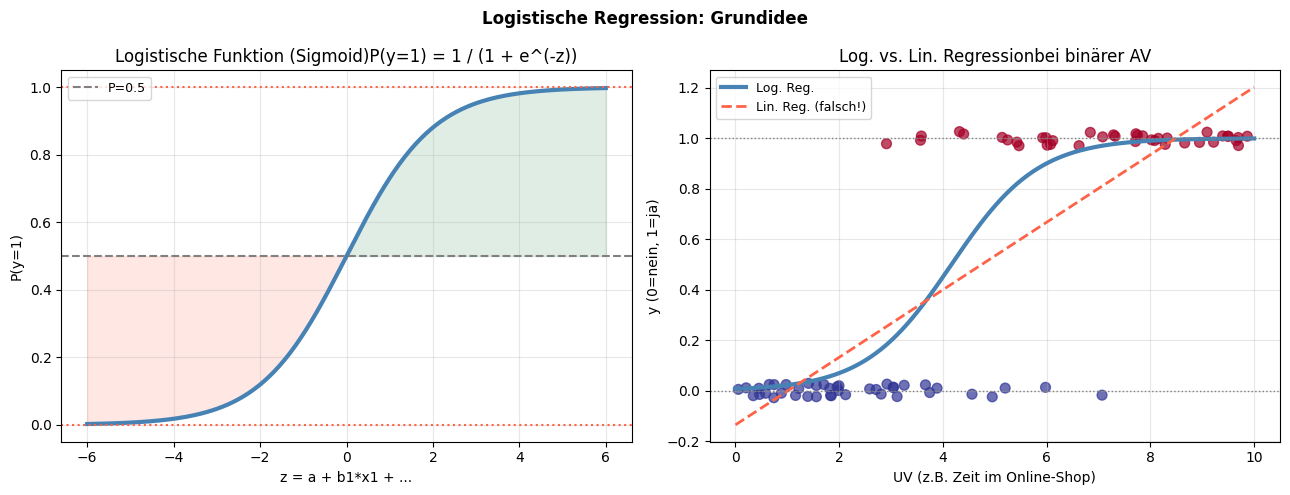

In [2]:
# Logistische Funktion visualisieren
z = np.linspace(-6, 6, 300)
sigmoid = expit(z)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistische Regression: Grundidee", fontsize=12, fontweight="bold")

# 1. Sigmoid-Funktion
axes[0].plot(z, sigmoid, color="steelblue", linewidth=3)
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1.5, label="P=0.5")
axes[0].axhline(1.0, color="tomato", linestyle=":", linewidth=1.5)
axes[0].axhline(0.0, color="tomato", linestyle=":", linewidth=1.5)
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid > 0.5), alpha=0.15, color="seagreen")
axes[0].fill_between(z, sigmoid, 0.5, where=(sigmoid < 0.5), alpha=0.15, color="tomato")
axes[0].set_title("Logistische Funktion (Sigmoid)P(y=1) = 1 / (1 + e^(-z))")
axes[0].set_xlabel("z = a + b1*x1 + ...")
axes[0].set_ylabel("P(y=1)")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(-0.05, 1.05)

# 2. Lineare vs. logistische Regression
np.random.seed(42)
n_vis = 80
x_vis = np.random.uniform(0, 10, n_vis)
logit_vis = -5 + 1.2 * x_vis
prob_vis = expit(logit_vis)
y_vis = (np.random.uniform(0, 1, n_vis) < prob_vis).astype(int)

axes[1].scatter(x_vis, y_vis + np.random.uniform(-0.03, 0.03, n_vis),
                c=y_vis, cmap="RdYlBu_r", s=50, alpha=0.7)
x_line = np.linspace(0, 10, 200)
logit_line = -5 + 1.2 * x_line
axes[1].plot(x_line, expit(logit_line), color="steelblue", linewidth=3,
             label="Log. Reg.")
m_lin, b_lin = np.polyfit(x_vis, y_vis, 1)
axes[1].plot(x_line, m_lin*x_line+b_lin, color="tomato", linewidth=2,
             linestyle="--", label="Lin. Reg. (falsch!)")
axes[1].axhline(0, color="gray", linestyle=":", linewidth=1)
axes[1].axhline(1, color="gray", linestyle=":", linewidth=1)
axes[1].set_title("Log. vs. Lin. Regressionbei binärer AV")
axes[1].set_xlabel("UV (z.B. Zeit im Online-Shop)")
axes[1].set_ylabel("y (0=nein, 1=ja)")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Das numiqo-Beispiel: Kaufverhalten im Online-Shop

**AV:** Kauft sofort (1) oder nicht (0)
**UV:** Geschlecht, Alter, Zeit im Shop

Wir simulieren den numiqo-Datensatz (n=150) für die **binäre** Variante
(kauft sofort vs. kauft nicht sofort).

In [3]:
# numiqo-Datensatz simulieren
np.random.seed(42)
n = 150
alter = np.random.normal(35, 12, n).clip(18, 70)
zeit  = np.random.exponential(40, n).clip(1, 200)
ist_w = np.random.choice([0, 1], n)  # 0=männlich, 1=weiblich

logit = -3.5 + 0.04*zeit - 0.01*alter + 0.3*ist_w
prob  = expit(logit)
kauft = (np.random.uniform(0, 1, n) < prob).astype(int)

df = pd.DataFrame({
    "kauft_sofort": kauft,
    "alter": alter,
    "zeit":  zeit,
    "ist_weiblich": ist_w
})

print("Datensatz Überblick")
print("n=" + str(n) + "  kauft_sofort: " + str(kauft.sum()) +
      " (" + str(round(kauft.mean()*100, 1)) + "%)")
print()
for g, name in [(0, "Männlich"), (1, "Weiblich")]:
    sub = df[df["ist_weiblich"] == g]
    rate = sub["kauft_sofort"].mean()
    print(name + ": n=" + str(len(sub)) + "  Kaufrate=" + str(round(rate*100,1)) + "%")
print()

# Logistische Regression
model = smf.logit("kauft_sofort ~ alter + zeit + ist_weiblich", data=df).fit(disp=0)

print("Logistische Regression")
print()
print("Modellgüte:")
print("  McFadden R2  = " + str(round(model.prsquared, 4)))
print("  Log-Lik.     = " + str(round(model.llf, 2)))
print("  Chi2-Test    = " + str(round(model.llr, 2)) +
      "  p=" + str(round(model.llr_pvalue, 4)))
print()
print("Koeffizienten (Logits):")
for name in model.params.index:
    b_v = model.params[name]
    p_v = model.pvalues[name]
    or_v = np.exp(b_v)
    sig = "*" if p_v < 0.05 else "n.s."
    print("  " + name + ": b=" + str(round(b_v,4)) +
          "  OR=" + str(round(or_v,3)) +
          "  p=" + str(round(p_v,4)) + " " + sig)

Datensatz Überblick
n=150  kauft_sofort: 27 (18.0%)

Männlich: n=82  Kaufrate=15.9%
Weiblich: n=68  Kaufrate=20.6%

Logistische Regression

Modellgüte:
  McFadden R2  = 0.301
  Log-Lik.     = -49.42
  Chi2-Test    = 42.57  p=0.0

Koeffizienten (Logits):
  Intercept: b=-2.2675  OR=0.104  p=0.0193 *
  alter: b=-0.0482  OR=0.953  p=0.0623 n.s.
  zeit: b=0.0394  OR=1.04  p=0.0 *
  ist_weiblich: b=0.7083  OR=2.03  p=0.1844 n.s.


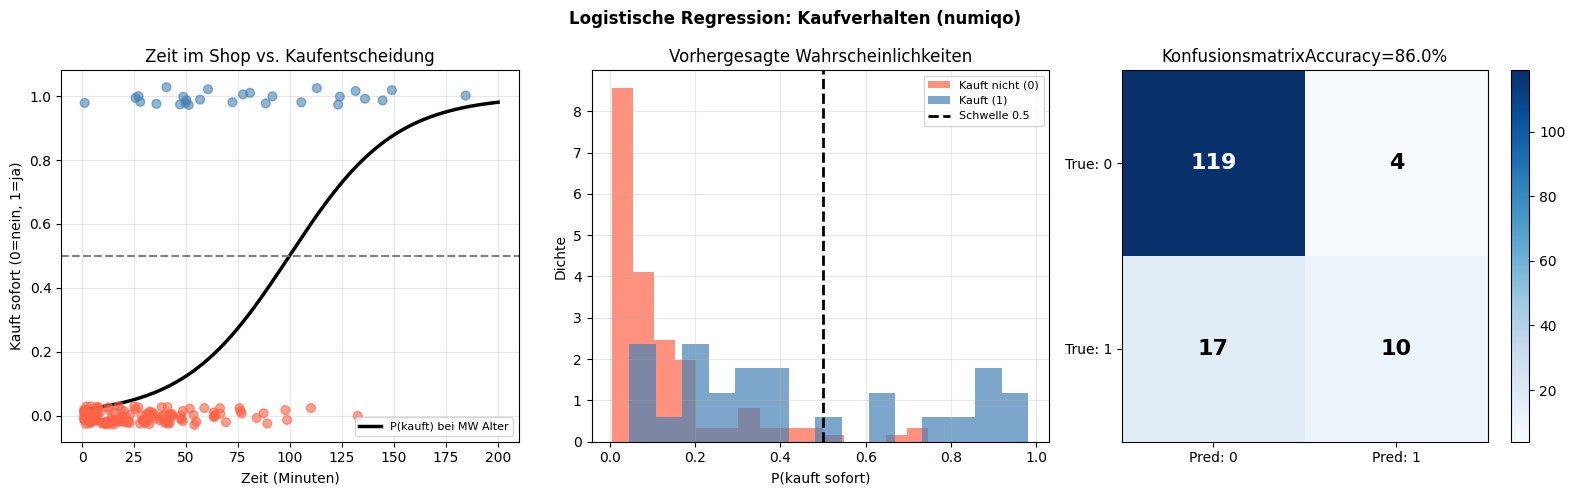

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Logistische Regression: Kaufverhalten (numiqo)", fontsize=12,
             fontweight="bold")

farben_k = {0: "tomato", 1: "steelblue"}
fc_list  = [farben_k[k] for k in kauft]

# 1. Zeit vs. Kaufwahrscheinlichkeit
axes[0].scatter(zeit, kauft + np.random.uniform(-0.03, 0.03, n),
                c=fc_list, s=40, alpha=0.6, zorder=3)
x_zeit = np.linspace(0, 200, 300)
alter_mw = alter.mean()
logit_z = model.params.iloc[0] + model.params.iloc[1]*alter_mw + model.params.iloc[2]*x_zeit
axes[0].plot(x_zeit, expit(logit_z), color="black", linewidth=2.5,
             label="P(kauft) bei MW Alter")
axes[0].axhline(0.5, color="gray", linestyle="--", linewidth=1.5)
axes[0].set_title("Zeit im Shop vs. Kaufentscheidung")
axes[0].set_xlabel("Zeit (Minuten)")
axes[0].set_ylabel("Kauft sofort (0=nein, 1=ja)")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Vorhergesagte Wahrscheinlichkeiten
pred_prob = model.predict(df)
axes[1].hist(pred_prob[kauft==0], bins=15, color="tomato", alpha=0.7,
             label="Kauft nicht (0)", density=True)
axes[1].hist(pred_prob[kauft==1], bins=15, color="steelblue", alpha=0.7,
             label="Kauft (1)", density=True)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=2, label="Schwelle 0.5")
axes[1].set_title("Vorhergesagte Wahrscheinlichkeiten")
axes[1].set_xlabel("P(kauft sofort)")
axes[1].set_ylabel("Dichte")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# 3. Konfusionsmatrix
schwelle = 0.5
pred_klasse = (pred_prob >= schwelle).astype(int)
tp = ((pred_klasse == 1) & (kauft == 1)).sum()
tn = ((pred_klasse == 0) & (kauft == 0)).sum()
fp = ((pred_klasse == 1) & (kauft == 0)).sum()
fn = ((pred_klasse == 0) & (kauft == 1)).sum()
acc = (tp + tn) / n

matrix = np.array([[tn, fp], [fn, tp]])
im = axes[2].imshow(matrix, cmap="Blues", aspect="auto")
plt.colorbar(im, ax=axes[2])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(matrix[i,j]), ha="center", va="center",
                     fontsize=16, fontweight="bold",
                     color="white" if matrix[i,j] > matrix.max()/2 else "black")
axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(["Pred: 0", "Pred: 1"])
axes[2].set_yticklabels(["True: 0", "True: 1"])
axes[2].set_title("KonfusionsmatrixAccuracy=" + str(round(acc*100, 1)) + "%")

plt.tight_layout()
plt.show()

## 3. Odds Ratios interpretieren

Der Regressionskoeffizient b gibt die Änderung des **Log-Odds** an.
Exponenziert ergibt er das **Odds Ratio (OR)**:

$$OR = e^b$$

| OR | Bedeutung |
|---|---|
| OR > 1 | UV erhöht die Chance für y=1 |
| OR = 1 | UV hat keinen Einfluss |
| OR < 1 | UV senkt die Chance für y=1 |

**Beispiel:** OR(Zeit) = 1,05 → Jede zusätzliche Minute im Shop erhöht
die Kaufchance um den Faktor 1,05 (= +5%).

In [5]:
print("Odds Ratios und Interpretation")
print()
print("Variable       b        OR      CI 95%         Interpretation")

conf = model.conf_int()
for name in model.params.index:
    b_v  = model.params[name]
    or_v = np.exp(b_v)
    ci_lo = np.exp(conf.iloc[list(model.params.index).index(name), 0])
    ci_hi = np.exp(conf.iloc[list(model.params.index).index(name), 1])
    if name == "Intercept":
        interp = "Basiswahrscheinlichkeit"
    elif or_v > 1.05:
        interp = "erhoehte Chance (+)"
    elif or_v < 0.95:
        interp = "reduzierte Chance (-)"
    else:
        interp = "kaum Einfluss"
    print(name + "  " + str(round(b_v,3)) + "  " + str(round(or_v,3)) +
          "  [" + str(round(ci_lo,3)) + ", " + str(round(ci_hi,3)) + "]  " + interp)

# Wahrscheinlichkeitsvorhersage
print()
print("Beispiel-Vorhersagen")
neue = pd.DataFrame({
    "alter": [25, 45, 30],
    "zeit":  [60, 10, 120],
    "ist_weiblich": [1, 0, 1]
})
preds = model.predict(neue)
print("Alter  Zeit  Geschlecht  P(kauft sofort)")
for i, (_, row) in enumerate(neue.iterrows()):
    g = "w" if row["ist_weiblich"] == 1 else "m"
    print(str(int(row["alter"])) + "     " + str(int(row["zeit"])) +
          "    " + g + "           " + str(round(preds.iloc[i], 4)) +
          "  -> " + ("kauft" if preds.iloc[i] >= 0.5 else "kauft nicht"))

Odds Ratios und Interpretation

Variable       b        OR      CI 95%         Interpretation
Intercept  -2.267  0.104  [0.015, 0.692]  Basiswahrscheinlichkeit
alter  -0.048  0.953  [0.906, 1.002]  kaum Einfluss
zeit  0.039  1.04  [1.024, 1.056]  kaum Einfluss
ist_weiblich  0.708  2.03  [0.713, 5.778]  erhoehte Chance (+)

Beispiel-Vorhersagen
Alter  Zeit  Geschlecht  P(kauft sofort)
25     60    w           0.4008  -> kauft nicht
45     10    m           0.0172  -> kauft nicht
30     120    w           0.8481  -> kauft


In [6]:
# APA-Ausgabe-Funktion
def logreg_apa(model_obj, abh_var="AV", alpha=0.05):
    print("Logistische Regression: " + abh_var)
    print("n=" + str(int(model_obj.nobs)))
    print()
    print("Modellgüte:")
    print("  McFadden R2 = " + str(round(model_obj.prsquared, 4)))
    print("  Chi2=" + str(round(model_obj.llr, 3)) +
          "  p=" + str(round(model_obj.llr_pvalue, 4)))
    print()
    print("Koeffizienten:")
    print("Variable       b       OR      p      sig")
    conf_i = model_obj.conf_int()
    for idx_n, name in enumerate(model_obj.params.index):
        b_v  = model_obj.params[name]
        or_v = np.exp(b_v)
        p_v  = model_obj.pvalues[name]
        sig  = "***" if p_v<0.001 else ("**" if p_v<0.01 else ("*" if p_v<0.05 else "n.s."))
        print(name + "  " + str(round(b_v,3)) + "  " +
              str(round(or_v,3)) + "  " + str(round(p_v,4)) + "  " + sig)
    print()

logreg_apa(model, "Kauft sofort (0/1)")

Logistische Regression: Kauft sofort (0/1)
n=150

Modellgüte:
  McFadden R2 = 0.301
  Chi2=42.571  p=0.0

Koeffizienten:
Variable       b       OR      p      sig
Intercept  -2.267  0.104  0.0193  *
alter  -0.048  0.953  0.0623  n.s.
zeit  0.039  1.04  0.0  ***
ist_weiblich  0.708  2.03  0.1844  n.s.



## 4. Zusammenfassung

```
Logistische Regression – Übersicht
│
├── WANN?
│   AV ist dichotom (0/1) oder nominal
│   Wahrscheinlichkeit P(y=1) schaetzen
│
├── KERNFORMEL
│   P(y=1) = 1 / (1 + e^(-z))
│   z = a + b1*x1 + b2*x2 + ... (Logit)
│
├── PARAMETER
│   Maximum-Likelihood (nicht OLS!)
│   Chi2-Test: Gesamtmodell signifikant?
│
├── INTERPRETATION
│   b:  Aenderung des Log-Odds bei +1 in UV
│   OR: e^b = Odds Ratio
│       OR > 1: erhoehte Chance
│       OR < 1: reduzierte Chance
│       OR = 1: kein Einfluss
│
├── GUTEMASSE (Pseudo-R2)
│   McFadden R2:  0.2-0.4 = gutes Modell
│   Nagelkerke R2: 0-1 (hoeher = besser)
│   Accuracy: Anteil korrekt klassifiziert
│
├── VARIANTEN
│   Binaer:     AV = 2 Klassen (0/1)
│   Multinomial: AV = 3+ Klassen -> k binare Modelle
│
├── numiqo-BEISPIEL: Kaufverhalten Online-Shop
│   UV: Alter, Zeit, Geschlecht -> AV: kauft sofort (0/1)
│   Zeit im Shop signifikant -> mehr Zeit = hoehere Kaufwahrsch.
│
└── PYTHON
    import statsmodels.formula.api as smf
    model = smf.logit("y ~ x1 + x2", data=df).fit()
    print(model.summary())
    pred = model.predict(neue_daten)  # gibt P(y=1) zurück
```

---
Quelle: [numiqo.de/tutorial/logistische-regression](https://numiqo.de/tutorial/logistische-regression)